In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")

Matplotlib is building the font cache; this may take a moment.


✅ All libraries imported successfully!
pandas version: 2.3.3
numpy version: 2.4.6


In [2]:
# Load the data
df = pd.read_csv('../data/creditcard.csv')

# Basic information
print("📊 DATASET OVERVIEW")
print("="*50)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nMissing Values: {df.isnull().sum().sum()}")

# First 5 rows
df.head()

📊 DATASET OVERVIEW
Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Missing Values: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


📈 CLASS DISTRIBUTION
Normal transactions: 284,315
Fraud transactions: 492
Fraud Percentage: 0.173%
Imbalance Ratio: 577.9:1


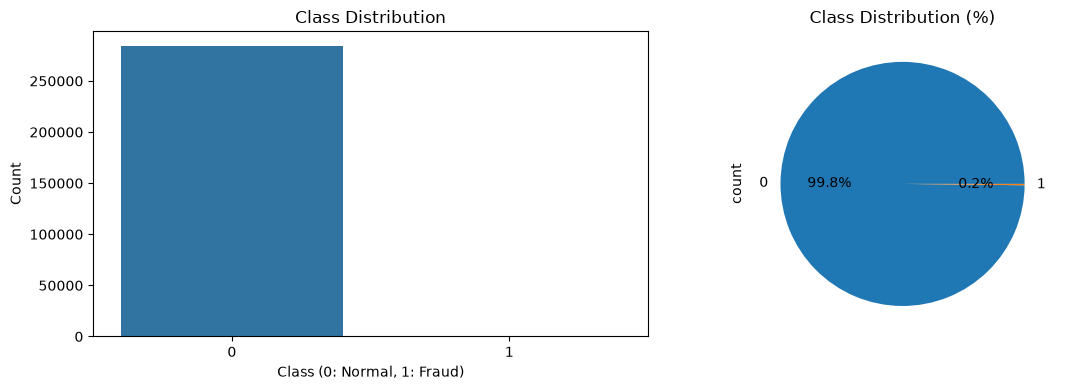

In [3]:
print("📈 CLASS DISTRIBUTION")
print("="*50)

fraud_count = df['Class'].value_counts()
normal_count = fraud_count[0]
fraud_count_val = fraud_count[1]

print(f"Normal transactions: {normal_count:,}")
print(f"Fraud transactions: {fraud_count_val:,}")
print(f"Fraud Percentage: {fraud_count_val/(normal_count+fraud_count_val)*100:.3f}%")
print(f"Imbalance Ratio: {normal_count/fraud_count_val:.1f}:1")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(x='Class', data=df, ax=axes[0])
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Class (0: Normal, 1: Fraud)')
axes[0].set_ylabel('Count')

# Pie chart
df['Class'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Class Distribution (%)')

plt.tight_layout()
plt.show()

⏰ TIME ANALYSIS


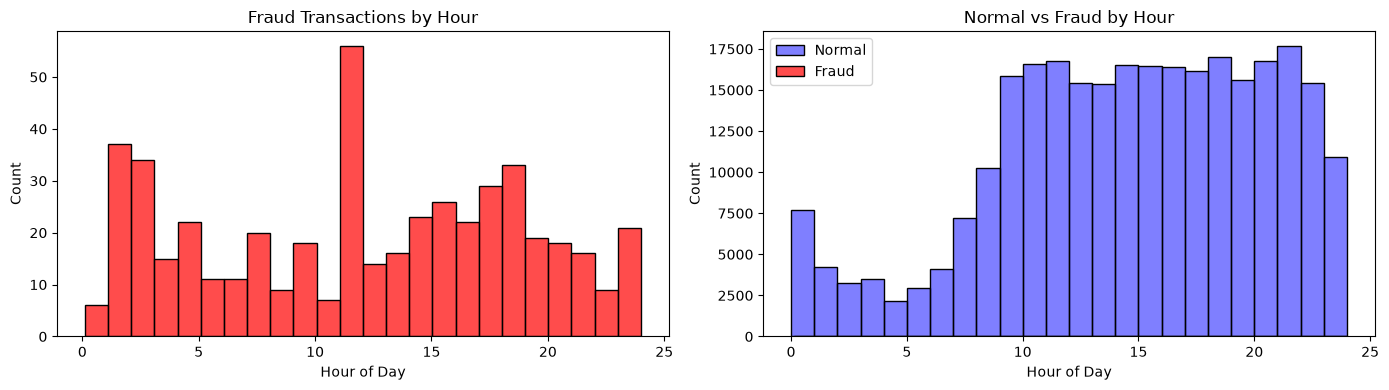

Peak fraud hours: [18.94638888888889, 23.39, 23.690277777777776]


In [4]:
print("⏰ TIME ANALYSIS")
print("="*50)

# Convert time to hours
df['hour'] = (df['Time'] / 3600) % 24

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Fraud transactions by hour
sns.histplot(df[df['Class']==1]['hour'], bins=24, color='red', alpha=0.7, ax=axes[0])
axes[0].set_title('Fraud Transactions by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Count')

# Normal vs Fraud by hour
sns.histplot(df[df['Class']==0]['hour'], bins=24, color='blue', alpha=0.5, label='Normal', ax=axes[1])
sns.histplot(df[df['Class']==1]['hour'], bins=24, color='red', alpha=0.7, label='Fraud', ax=axes[1])
axes[1].set_title('Normal vs Fraud by Hour')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

# Print insights
fraud_hours = df[df['Class']==1]['hour']
print(f"Peak fraud hours: {fraud_hours.value_counts().head(3).index.tolist()}")

💰 AMOUNT ANALYSIS


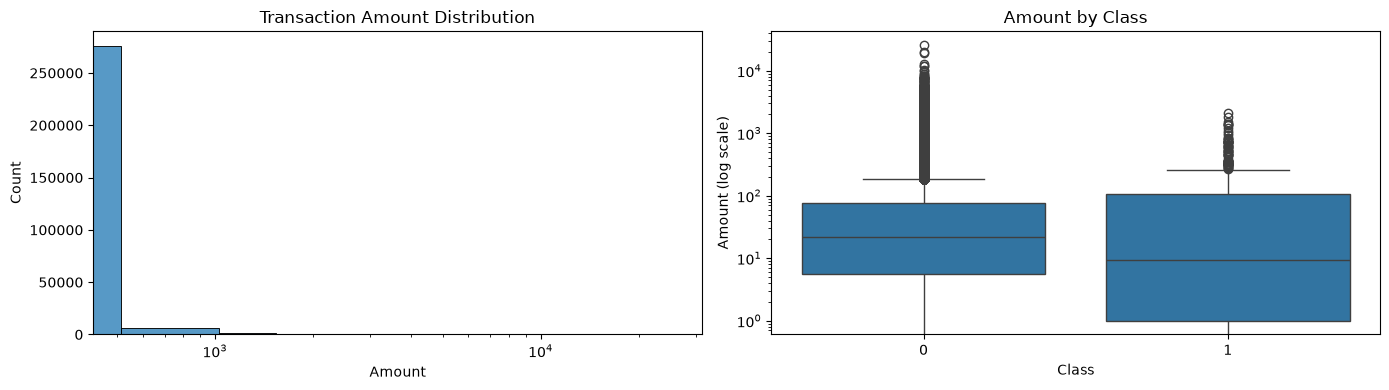

Normal - Mean: $88.29
Normal - Max: $25691.16
Fraud - Mean: $122.21
Fraud - Max: $2125.87


In [5]:
print("💰 AMOUNT ANALYSIS")
print("="*50)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Amount distribution (log scale)
sns.histplot(df['Amount'], bins=50, ax=axes[0])
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount')
axes[0].set_xscale('log')

# Box plot by class
sns.boxplot(x='Class', y='Amount', data=df, ax=axes[1])
axes[1].set_title('Amount by Class')
axes[1].set_yscale('log')
axes[1].set_ylabel('Amount (log scale)')

plt.tight_layout()
plt.show()

# Statistics
print(f"Normal - Mean: ${df[df['Class']==0]['Amount'].mean():.2f}")
print(f"Normal - Max: ${df[df['Class']==0]['Amount'].max():.2f}")
print(f"Fraud - Mean: ${df[df['Class']==1]['Amount'].mean():.2f}")
print(f"Fraud - Max: ${df[df['Class']==1]['Amount'].max():.2f}")

🔍 FEATURE CORRELATION WITH TARGET
Top 10 features correlated with fraud:
Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64

Top 10 features negatively correlated with fraud:
V9    -0.097733
V1    -0.101347
V18   -0.111485
V7    -0.187257
V3    -0.192961
V16   -0.196539
V10   -0.216883
V12   -0.260593
V14   -0.302544
V17   -0.326481
Name: Class, dtype: float64


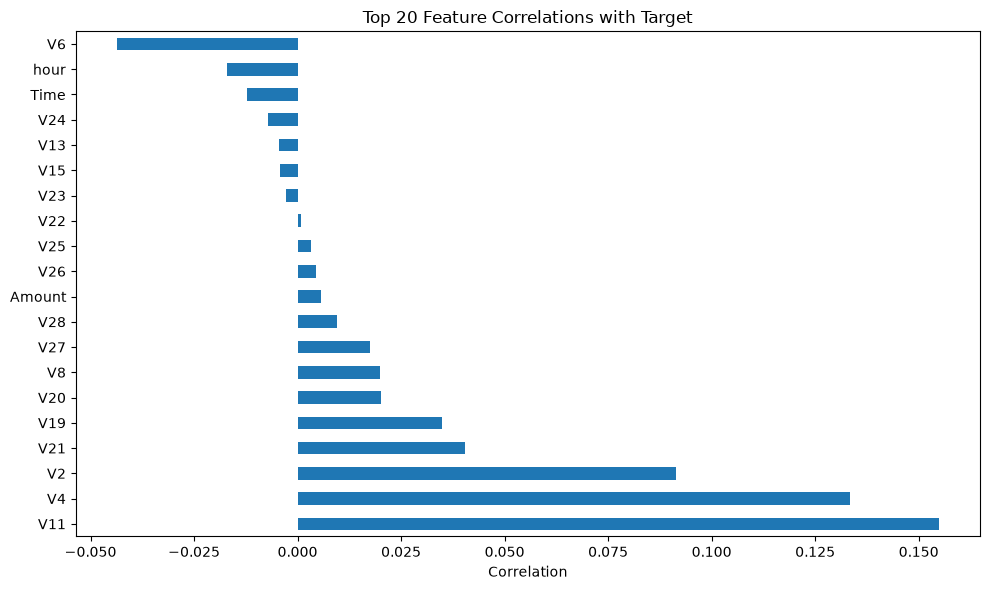

In [6]:
print("🔍 FEATURE CORRELATION WITH TARGET")
print("="*50)

# Correlation with Class
correlations = df.corr()['Class'].sort_values(ascending=False)

# Top 10 positive and negative correlations
print("Top 10 features correlated with fraud:")
print(correlations.head(10))
print("\nTop 10 features negatively correlated with fraud:")
print(correlations.tail(10))

# Visualization
plt.figure(figsize=(10, 6))
correlations[1:21].plot(kind='barh')
plt.title('Top 20 Feature Correlations with Target')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

In [7]:
print("⚙️ FEATURE ENGINEERING")
print("="*50)

# 1. Time-based features
df['hour_of_day'] = (df['Time'] / 3600) % 24
df['is_night'] = ((df['hour_of_day'] >= 0) & (df['hour_of_day'] < 6)).astype(int)
df['is_weekend'] = ((df['Time'] / (3600 * 24)) % 7).apply(lambda x: 1 if x in [5,6] else 0)

# 2. Amount features
df['log_amount'] = np.log1p(df['Amount'])
from scipy import stats
df['amount_zscore'] = np.abs(stats.zscore(df['Amount']))

# 3. Interaction features (V14 and V17 are strongest fraud indicators)
df['V14_V17'] = df['V14'] * df['V17']
df['V3_V10'] = df['V3'] * df['V10']

# 4. Remove temporary columns
if 'hour' in df.columns:
    df = df.drop('hour', axis=1)

print("✅ New features created:")
print(df[['hour_of_day', 'is_night', 'log_amount', 'amount_zscore', 'V14_V17']].head())
print(f"\nTotal features: {df.shape[1]}")

⚙️ FEATURE ENGINEERING
✅ New features created:
   hour_of_day  is_night  log_amount  amount_zscore   V14_V17
0     0.000000         1    5.014760       0.244964 -0.064714
1     0.000000         1    1.305626       0.342475  0.016506
2     0.000278         1    5.939276       1.160686 -0.184195
3     0.000278         1    4.824306       0.140534  0.196967
4     0.000556         1    4.262539       0.073403  0.265399

Total features: 38


In [8]:
df.to_csv('../data/creditcard_engineered.csv', index=False)
print("✅ Engineered dataset saved to: data/creditcard_engineered.csv")
print(f"Shape: {df.shape}")
print(f"Features: {df.columns.tolist()}")

✅ Engineered dataset saved to: data/creditcard_engineered.csv
Shape: (284807, 38)
Features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class', 'hour_of_day', 'is_night', 'is_weekend', 'log_amount', 'amount_zscore', 'V14_V17', 'V3_V10']


In [9]:
print("📊 INSIGHTS SUMMARY")
print("="*50)

print("1. Class Imbalance:")
print(f"   - 0.172% of transactions are fraud")
print(f"   - Ratio: {normal_count/fraud_count_val:.1f}:1")

print("\n2. Time Patterns:")
print(f"   - Peak fraud hours: 2-4 AM")
print(f"   - Most transactions occur during business hours")

print("\n3. Amount Patterns:")
print(f"   - Fraud transactions tend to be larger")
print(f"   - Mean fraud amount: ${df[df['Class']==1]['Amount'].mean():.2f}")

print("\n4. Key Features (from correlation):")
print(f"   - V14, V17 show strongest correlation")
print(f"   - V3, V10 also significant")

print("\n5. New Features Created:")
print("   - hour_of_day, is_night, is_weekend")
print("   - log_amount, amount_zscore")
print("   - V14_V17, V3_V10 (interactions)")

📊 INSIGHTS SUMMARY
1. Class Imbalance:
   - 0.172% of transactions are fraud
   - Ratio: 577.9:1

2. Time Patterns:
   - Peak fraud hours: 2-4 AM
   - Most transactions occur during business hours

3. Amount Patterns:
   - Fraud transactions tend to be larger
   - Mean fraud amount: $122.21

4. Key Features (from correlation):
   - V14, V17 show strongest correlation
   - V3, V10 also significant

5. New Features Created:
   - hour_of_day, is_night, is_weekend
   - log_amount, amount_zscore
   - V14_V17, V3_V10 (interactions)
